# CleanGanga-Prayagraj — Data Quality & Exploratory Analysis

## Project
**AI-Assisted Ganga Water Quality Assessment and Decision Support**

### Primary SDG
**SDG 6 — Clean Water and Sanitation**

### Purpose of this notebook
This notebook performs **data understanding, data-quality assessment, and exploratory data analysis (EDA)** on the Prayagraj/Allahabad river-monitoring records.

The goal is to understand:
- what data is available,
- whether the data is usable,
- where missing or invalid values exist,
- how water-quality measurements are distributed,
- how observations differ across monitoring stations, and
- which variables are appropriate for later analytical/modeling work.

### Important design decision
The bathing-water assessment is kept **transparent and rule-based**. We do **not** treat a threshold-derived label as independent ground truth for machine learning.

The later ML stage will be designed separately so that we do not accidentally train a model to reproduce the same rule that created its target.

### Engineering approach
This project follows:
**Build → Measure → Explain → Improve → Repeat**

Important decisions, assumptions, limitations, and experiments should be recorded in `docs/decisions.md` and `docs/experiments.md`.

## 1. Imports

We use:
- **Pandas** for tabular data analysis
- **NumPy** for numerical operations
- **Matplotlib** for visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load the dataset

The notebook is expected to live in:

`notebooks/01_data_quality.ipynb`

and the dataset in:

`data/Prayagraj_Data.csv`

Using a relative path makes the project easier to reproduce on another computer.

In [2]:
from pathlib import Path

DATA_PATH = Path("../data/Prayagraj_Data.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (1414, 23)


## 3. Understand the dataset structure

Before changing anything, inspect the dataset as it was provided.

Questions:
- How many observations are there?
- What columns exist?
- What are the data types?
- Which columns contain missing values?

In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Shape: (1414, 23)

Columns:
['SlNo', 'Station', 'Agency', 'State LGD Code', 'State', 'District LGD Code', 'District', 'Tehsil', 'Block', 'Village', 'River', 'Basin', 'Tributary', 'Subtributary', 'SubSubtributary', 'Local River', 'Latitude', 'Longitude', 'Data Acquisition Time', 'Biochemical Oxygen Demand (mg/L)', 'Chemical Oxygen Demand (mg/L)', 'Fecal Coliform (MPN/100mL)', 'Total Coliform (MPN/100mL)']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1414 entries, 0 to 1413
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   SlNo                              1414 non-null   int64  
 1   Station                           1414 non-null   str    
 2   Agency                            1414 non-null   str    
 3   State LGD Code                    1414 non-null   int64  
 4   State                             1414 non-null   str    
 5   District LGD Code           

## 4. Inspect the geographical scope

The source dataset uses **"Allahabad"** as the district name for the area now commonly referred to as Prayagraj.

We therefore filter the records using the value present in the source data rather than silently changing the raw dataset.

In [4]:
print("Districts available in the dataset:")
print(df["District"].dropna().unique())

Districts available in the dataset:
<ArrowStringArray>
[         'G.B. Nagar',       'MUZAFFARNAGAR',             'BAGHPAT',
            'HAMIRPUR',              'JHANSI',              'RAMPUR',
           'MORADABAD',           'Allahabad',        'KANPUR NAGAR',
           'Raibareli', 'JYOTIBA PHULE NAGAR',              'BUDAUN',
          'PRATAPGARH',             'KANNAUJ',              'HARDOI',
               'UNNAO',       'Buland Shahar',            'GHAZIPUR',
            'VARANASI',            'MIRZAPUR',              'DEORIA',
             'JAUNPUR',             'LUCKNOW',             'SITAPUR',
            'LALITPUR',           'GHAZIABAD',              'JALAUN',
              'BIJNOR',           'GORAKHPUR',           'SONBHADRA',
  'SANT RAVIDAS NAGAR',         'FARRUKHABAD',           'BARABANKI',
             'Ayodhya',               'KHERI',              'MEERUT',
                'AGRA',              'ETAWAH',             'AURAIYA',
             'MATHURA']
Length: 40,

In [5]:
prayagraj = df[df["District"] == "Allahabad"].copy()

print("Prayagraj/Allahabad records:", len(prayagraj))
print("Unique stations:", prayagraj["Station"].nunique())

print("\nObservations per station:")
print(prayagraj["Station"].value_counts())

Prayagraj/Allahabad records: 116
Unique stations: 6

Observations per station:
Station
GANGA AT ALLAHABAD D/S (SANGAM) U.P.           24
GANGA AT ALLAHABAD (RASOOLABAD) U.P.           24
GANGA AT KADAGHAT ALLAHABAD                    24
RIVER GANGA A/C TAMSA RIVER SIRSA SON BARSA    24
YAMUNA AT ALLAHABAD D/S (BALUA GHAT) U.P       11
TONS AT CHAKGHAT M.P.                           9
Name: count, dtype: int64


## 5. Inspect the water-quality parameters

First identify the water-quality columns present in the source dataset.

We do not assume that every listed parameter is usable. A parameter may exist in the schema but contain no actual observations.

In [6]:
measurement_columns = [
    "Biochemical Oxygen Demand (mg/L)",
    "Chemical Oxygen Demand (mg/L)",
    "Fecal Coliform (MPN/100mL)",
    "Total Coliform (MPN/100mL)"
]

print("Water-quality parameters:")
for i, column in enumerate(measurement_columns, start=1):
    print(f"{i}. {column}")

Water-quality parameters:
1. Biochemical Oxygen Demand (mg/L)
2. Chemical Oxygen Demand (mg/L)
3. Fecal Coliform (MPN/100mL)
4. Total Coliform (MPN/100mL)


## 6. Convert measurement fields to numeric values

Measurements should be numeric before statistical analysis.

If a value cannot be converted safely, it becomes `NaN`. We preserve the missingness instead of inventing a value at this stage.

In [7]:
for column in measurement_columns:
    prayagraj[column] = pd.to_numeric(
        prayagraj[column],
        errors="coerce"
    )

print("Data types after conversion:")
print(prayagraj[measurement_columns].dtypes)

Data types after conversion:
Biochemical Oxygen Demand (mg/L)    float64
Chemical Oxygen Demand (mg/L)       float64
Fecal Coliform (MPN/100mL)          float64
Total Coliform (MPN/100mL)          float64
dtype: object


## 7. Missing-value analysis

Missing data is a data-quality problem, not something to hide.

We calculate both:
- the number of missing values, and
- the percentage of missing values.

### Decision rule used here
- **100% missing:** the feature cannot contribute information and will be excluded from current analysis.
- **Small amount of missingness:** retain the feature, but do not impute values before creating a threshold-based environmental assessment.

In [8]:
missing_data = pd.DataFrame({
    "Missing Values": prayagraj[measurement_columns].isna().sum(),
    "Missing Percentage": (prayagraj[measurement_columns].isna().mean() * 100)})

missing_data.sort_values(by="Missing Percentage",ascending=False)

,Missing Values,Missing Percentage
Chemical Oxygen Demand (mg/L),116,100.000000
Total Coliform (MPN/100mL),116,100.000000
Fecal Coliform (MPN/100mL),8,6.896552
Biochemical Oxygen Demand (mg/L),1,0.862069


## 8. Inspect rows with missing measurements

Before deciding how to handle missing values, inspect the affected observations.

This helps distinguish:
- isolated missing measurements,
- station-specific patterns, and
- systematic missingness.

In [9]:
missing_rows = prayagraj[
    prayagraj[
        [
            "Biochemical Oxygen Demand (mg/L)",
            "Fecal Coliform (MPN/100mL)"
        ]
    ].isna().any(axis=1)
]

missing_rows[
    [
        "Station",
        "Data Acquisition Time",
        "Biochemical Oxygen Demand (mg/L)",
        "Fecal Coliform (MPN/100mL)"
    ]
]

,Station,Data Acquisition Time,Biochemical Oxygen Demand (mg/L),Fecal Coliform (MPN/100mL)
108,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,30-12-2021 08:30,2.9,NaN
132,GANGA AT ALLAHABAD (RASOOLABAD) U.P.,30-12-2021 08:30,2.7,NaN
220,GANGA AT KADAGHAT ALLAHABAD,26-07-2021 08:30,NaN,220.0
230,GANGA AT KADAGHAT ALLAHABAD,30-12-2021 08:30,2.7,NaN
837,RIVER GANGA A/C TAMSA RIVER SIRSA SON BARSA,30-12-2021 08:30,2.7,NaN
1270,TONS AT CHAKGHAT M.P.,11-05-2021 08:30,1.1,NaN
1272,TONS AT CHAKGHAT M.P.,06-07-2021 08:30,1.8,NaN
1275,TONS AT CHAKGHAT M.P.,04-10-2021 08:30,1.7,NaN
1276,TONS AT CHAKGHAT M.P.,09-11-2021 08:30,1.9,NaN


## 9. Remove unusable parameters from the analysis copy

Chemical Oxygen Demand and Total Coliform contain no observations in this subset if the missing-value audit confirms 100% missingness.

We remove them from the **analysis copy**, while keeping the original `df` unchanged.

This is an explicit data-quality decision rather than silent deletion.

In [10]:
usable_measurements = [
    column for column in measurement_columns
    if prayagraj[column].notna().any()
]

unusable_measurements = [
    column for column in measurement_columns
    if not prayagraj[column].notna().any()
]

print("Usable measurement columns:")
print(usable_measurements)

print("\nExcluded because they contain no observations:")
print(unusable_measurements)

prayagraj_analysis = prayagraj.drop(
    columns=unusable_measurements
).copy()

Usable measurement columns:
['Biochemical Oxygen Demand (mg/L)', 'Fecal Coliform (MPN/100mL)']

Excluded because they contain no observations:
['Chemical Oxygen Demand (mg/L)', 'Total Coliform (MPN/100mL)']


## 10. Duplicate-record check

Duplicate observations can distort statistics and model evaluation.

We first count exact duplicate rows. We do not automatically delete them because repeated measurements can be legitimate; any removal should be justified by the data-generation process.

In [11]:
duplicate_count = prayagraj_analysis.duplicated().sum()

print("Exact duplicate rows:", duplicate_count)

Exact duplicate rows: 0


## 11. Basic descriptive statistics

Now we summarize the usable water-quality measurements.

Key statistics:
- `mean`: average
- `std`: spread
- `min` / `max`: observed range
- `25%`, `50%`, `75%`: quartiles

In [12]:
prayagraj_analysis[usable_measurements].describe().T

,count,mean,std,min,25%,50%,75%,max
Biochemical Oxygen Demand (mg/L),115.0,2.584348,0.318877,1.1,2.6,2.7,2.8,2.9
Fecal Coliform (MPN/100mL),108.0,862.500000,294.255674,2.0,707.5,825.0,1100.0,1400.0


## 12. Bathing-water assessment criteria

For the current project prototype, we use the bathing-water criteria already selected during the project work:

- **BOD limit:** 3 mg/L
- **Fecal Coliform desirable limit:** 500 MPN/100mL
- **Fecal Coliform maximum limit:** 2500 MPN/100mL

These thresholds form a **transparent environmental assessment layer**.

They are not presented as a learned ML ground truth.

In [13]:
BOD_LIMIT = 3.0
FC_DESIRABLE = 500
FC_MAXIMUM = 2500

print("BOD limit:", BOD_LIMIT, "mg/L")
print("FC desirable limit:", FC_DESIRABLE, "MPN/100mL")
print("FC maximum limit:", FC_MAXIMUM, "MPN/100mL")

BOD limit: 3.0 mg/L
FC desirable limit: 500 MPN/100mL
FC maximum limit: 2500 MPN/100mL


## 13. Create a complete-case assessment dataset

Because the environmental assessment directly depends on BOD and Fecal Coliform, we should **not median-impute these measurements before creating the assessment label**.

Instead, observations with missing BOD or Fecal Coliform are excluded from this particular rule-based assessment and remain documented as missing in the original data.

This prevents us from creating an artificial environmental measurement and then treating the resulting label as ground truth.

In [14]:
assessment_df = prayagraj_analysis.dropna(
    subset=[
        "Biochemical Oxygen Demand (mg/L)",
        "Fecal Coliform (MPN/100mL)"
    ]
).copy()

print("Original Prayagraj observations:", len(prayagraj_analysis))
print("Complete observations for threshold assessment:", len(assessment_df))
print("Excluded because BOD or Fecal Coliform was missing:",
      len(prayagraj_analysis) - len(assessment_df))

Original Prayagraj observations: 116
Complete observations for threshold assessment: 107
Excluded because BOD or Fecal Coliform was missing: 9


## 14. Create transparent environmental indicators

These boolean indicators answer simple domain questions:

- Does BOD exceed its selected limit?
- Does Fecal Coliform exceed the desirable level?
- Does Fecal Coliform exceed the maximum level?

These are deterministic rules, so their behavior is directly explainable.

In [15]:
assessment_df["BOD_exceeds"] = (
    assessment_df["Biochemical Oxygen Demand (mg/L)"] > BOD_LIMIT
)

assessment_df["FC_above_desirable"] = (
    assessment_df["Fecal Coliform (MPN/100mL)"] > FC_DESIRABLE
)

assessment_df["FC_exceeds_maximum"] = (
    assessment_df["Fecal Coliform (MPN/100mL)"] > FC_MAXIMUM
)

assessment_df[
    [
        "Station",
        "Biochemical Oxygen Demand (mg/L)",
        "Fecal Coliform (MPN/100mL)",
        "BOD_exceeds",
        "FC_above_desirable",
        "FC_exceeds_maximum"
    ]
].head(10)

,Station,Biochemical Oxygen Demand (mg/L),Fecal Coliform (MPN/100mL),BOD_exceeds,FC_above_desirable,FC_exceeds_maximum
85,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.0,790.0,False,True,False
86,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.6,1300.0,False,True,False
87,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.6,930.0,False,True,False
88,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.5,1100.0,False,True,False
89,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.7,1200.0,False,True,False
90,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.8,1400.0,False,True,False
91,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.7,1300.0,False,True,False
92,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.7,1100.0,False,True,False
93,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.6,1200.0,False,True,False
94,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.8,1200.0,False,True,False


## 15. Transparent pollution assessment

For communication and decision-support purposes, we create three rule-based levels:

- **High Pollution:** Fecal Coliform exceeds the maximum selected limit.
- **Moderate Pollution:** BOD exceeds its limit OR Fecal Coliform exceeds the desirable level.
- **Low Pollution:** both indicators are within the selected limits.

### Important
This `Pollution_Level` is a **rule-derived assessment**, not independent ground truth.

Therefore, it should not be used to claim that an ML model has independently learned pollution from the same BOD/FC variables.

In [16]:
def classify_pollution(row):
    if row["FC_exceeds_maximum"]:
        return "High Pollution"
    elif row["BOD_exceeds"] or row["FC_above_desirable"]:
        return "Moderate Pollution"
    else:
        return "Low Pollution"


assessment_df["Pollution_Level"] = assessment_df.apply(
    classify_pollution,
    axis=1
)

print("Rule-based assessment distribution:")
print(assessment_df["Pollution_Level"].value_counts())

Rule-based assessment distribution:
Pollution_Level
Moderate Pollution    100
Low Pollution           7
Name: count, dtype: int64


## 16. Inspect the rule-based assessment

This table allows us to audit individual classifications instead of treating the result as a black box.

In [17]:
assessment_df[
    [
        "Station",
        "Biochemical Oxygen Demand (mg/L)",
        "Fecal Coliform (MPN/100mL)",
        "BOD_exceeds",
        "FC_above_desirable",
        "FC_exceeds_maximum",
        "Pollution_Level"
    ]
].head(20)

,Station,Biochemical Oxygen Demand (mg/L),Fecal Coliform (MPN/100mL),BOD_exceeds,FC_above_desirable,FC_exceeds_maximum,Pollution_Level
85,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.0,790.0,False,True,False,Moderate Pollution
86,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.6,1300.0,False,True,False,Moderate Pollution
87,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.6,930.0,False,True,False,Moderate Pollution
88,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.5,1100.0,False,True,False,Moderate Pollution
89,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.7,1200.0,False,True,False,Moderate Pollution
90,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.8,1400.0,False,True,False,Moderate Pollution
91,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.7,1300.0,False,True,False,Moderate Pollution
92,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.7,1100.0,False,True,False,Moderate Pollution
93,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.6,1200.0,False,True,False,Moderate Pollution
94,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.8,1200.0,False,True,False,Moderate Pollution


## 17. Distribution of rule-based pollution levels

The class distribution is useful for understanding the assessment dataset.

If one class dominates, that will matter later when designing an ML evaluation strategy.

Pollution_Level
Moderate Pollution    100
Low Pollution           7
Name: count, dtype: int64


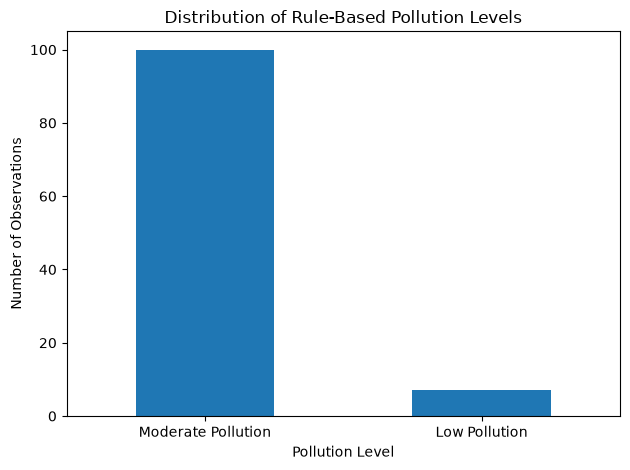

In [18]:
pollution_counts = assessment_df["Pollution_Level"].value_counts()

print(pollution_counts)

pollution_counts.plot(kind="bar")
plt.title("Distribution of Rule-Based Pollution Levels")
plt.xlabel("Pollution Level")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 18. Compare measurements across assessment levels

We compare the underlying measurements across the rule-derived levels.

This is EDA: we are investigating whether the observed measurements behave differently across the categories.

In [19]:
assessment_df.groupby("Pollution_Level")[
    [
        "Biochemical Oxygen Demand (mg/L)",
        "Fecal Coliform (MPN/100mL)"
    ]
].agg(["count", "mean", "min", "max"])

Biochemical Oxygen Demand (mg/L)                      \
                                              count      mean  min  max   
Pollution_Level                                                           
Low Pollution                                     7  2.014286  1.5  2.7   
Moderate Pollution                              100  2.656000  1.9  2.9   

                   Fecal Coliform (MPN/100mL)                             
                                        count        mean    min     max  
Pollution_Level                                                           
Low Pollution                               7  135.714286    2.0   490.0  
Moderate Pollution                        100  919.800000  600.0  1400.0

## 19. BOD distribution by assessment level

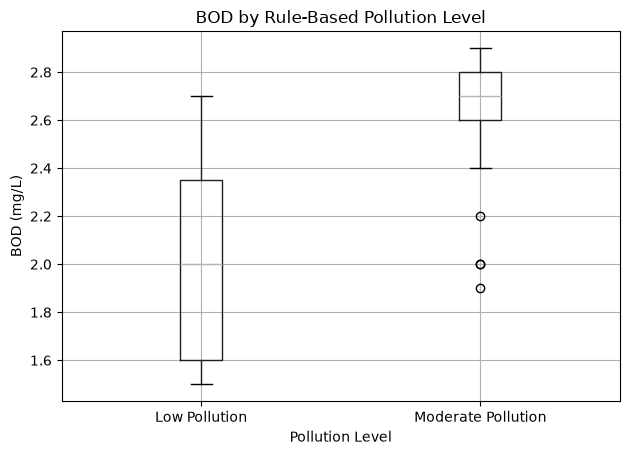

In [20]:
assessment_df.boxplot(
    column="Biochemical Oxygen Demand (mg/L)",
    by="Pollution_Level"
)

plt.title("BOD by Rule-Based Pollution Level")
plt.suptitle("")
plt.xlabel("Pollution Level")
plt.ylabel("BOD (mg/L)")
plt.tight_layout()
plt.show()

## 20. Fecal Coliform distribution by assessment level

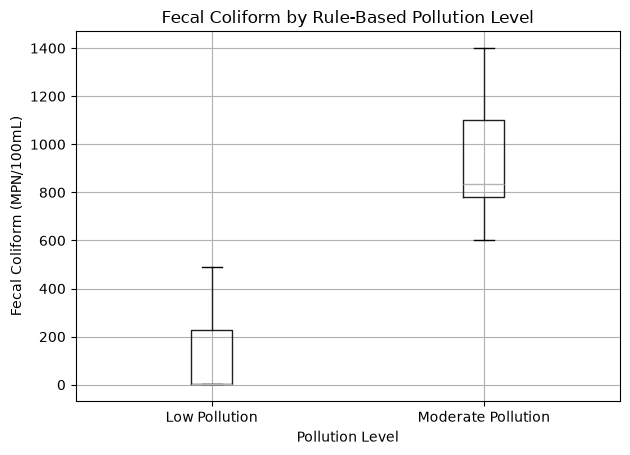

In [21]:
assessment_df.boxplot(
    column="Fecal Coliform (MPN/100mL)",
    by="Pollution_Level"
)

plt.title("Fecal Coliform by Rule-Based Pollution Level")
plt.suptitle("")
plt.xlabel("Pollution Level")
plt.ylabel("Fecal Coliform (MPN/100mL)")
plt.tight_layout()
plt.show()

## 21. Distribution of key measurements

Histograms help us understand the spread, concentration, and possible skewness of the two main measurements.

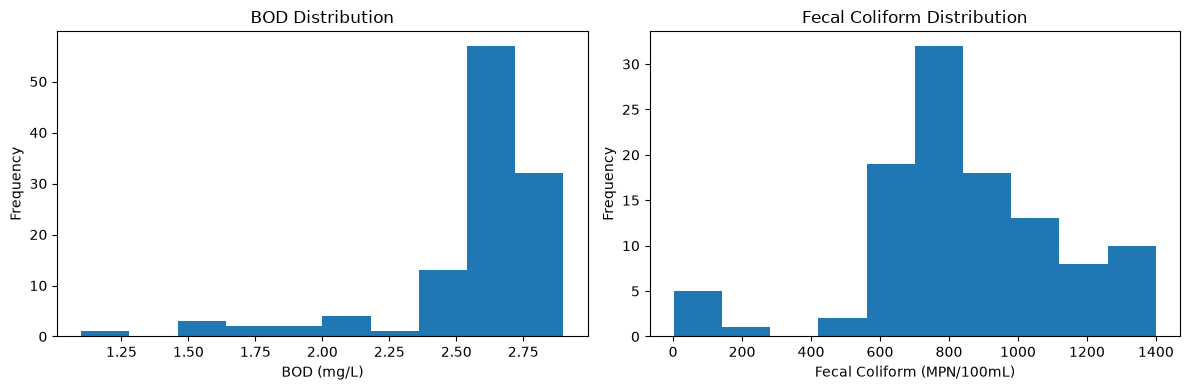

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    prayagraj_analysis["Biochemical Oxygen Demand (mg/L)"].dropna(),
    bins=10
)
axes[0].set_title("BOD Distribution")
axes[0].set_xlabel("BOD (mg/L)")
axes[0].set_ylabel("Frequency")

axes[1].hist(
    prayagraj_analysis["Fecal Coliform (MPN/100mL)"].dropna(),
    bins=10
)
axes[1].set_title("Fecal Coliform Distribution")
axes[1].set_xlabel("Fecal Coliform (MPN/100mL)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 22. Correlation analysis

Correlation helps us inspect linear relationships between numerical variables.

We exclude obvious identifiers and administrative codes from this interpretation because a numeric code does not automatically represent a meaningful continuous measurement.

Correlation does **not** establish causation.

In [23]:
correlation_features = [
    column for column in [
        "Latitude",
        "Longitude",
        "Biochemical Oxygen Demand (mg/L)",
        "Fecal Coliform (MPN/100mL)"
    ]
    if column in prayagraj_analysis.columns
]

correlation_matrix = prayagraj_analysis[
    correlation_features
].corr()

correlation_matrix

,Latitude,Longitude,Biochemical Oxygen Demand (mg/L),Fecal Coliform (MPN/100mL)
Latitude,1.000000,-0.130519,0.688577,0.608444
Longitude,-0.130519,1.000000,0.381538,0.133736
Biochemical Oxygen Demand (mg/L),0.688577,0.381538,1.000000,0.539380
Fecal Coliform (MPN/100mL),0.608444,0.133736,0.539380,1.000000


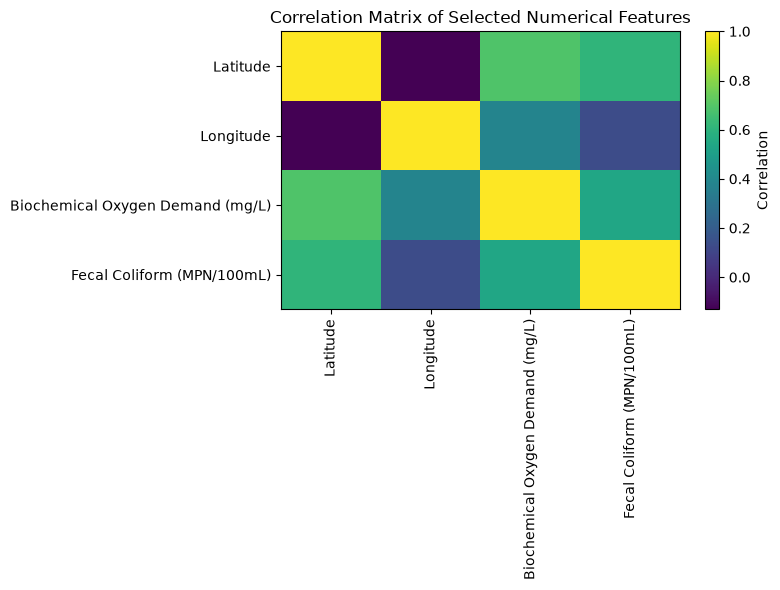

In [24]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Selected Numerical Features")
plt.tight_layout()
plt.show()

In [25]:
from pathlib import Path

OUTPUT_PATH = Path("../data/prayagraj_assessment.csv")

assessment_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print(f"Saved prepared assessment data to: {OUTPUT_PATH}")

Saved prepared assessment data to: ..\data\prayagraj_assessment.csv


## 23. Data-quality conclusion

At the end of this notebook we should be able to answer:

1. **What data do we have?**
2. **Which water-quality parameters are actually populated?**
3. **Where are the missing values?**
4. **Are there duplicate observations?**
5. **How are BOD and Fecal Coliform distributed?**
6. **How do measurements vary across monitoring stations and assessment levels?**
7. **Which variables are reasonable candidates for later analysis?**
8. **What limitations must be carried into the ML stage?**

### Key limitation discovered
The rule-based `Pollution_Level` is constructed directly from BOD and Fecal Coliform. Therefore, using those same variables to predict that label would create **target leakage**.

The next notebook should therefore define an ML objective that has a defensible target and evaluation strategy rather than simply reproducing the threshold rule.

## 24. Reproducibility notes

For this project, record:
- dataset source and version,
- filtering decisions,
- missing-value decisions,
- environmental thresholds and their source,
- feature-selection decisions,
- experiments and measured results,
- known limitations.

Do not commit API keys or secrets to Git.

The engineering-focused project guide emphasizes a baseline-first workflow, measurable evaluation, explicit failure handling, reproducibility, and documentation of decisions rather than adding technology for its own sake.